# A. Table of content:

- [B. Instructions:](#B.-Instructions:)  
- [C. Import, functions, & data load:](#C.-Import,-functions,-&-data-load:)  
- [1. Data wrangling:](#1.-Data-wrangling:)  
    - [1.1. Data cleaning:](#1.1.-Data-cleaning:)  
    - [1.2. Text normalization:](#1.2.-Text-normalization:)  
- [2. Exploratory data analysis, EDA:](#2.-Exploratory-data-analysis,-EDA:)  
    - [2.1. Target label balance:](#2.1.-Target-label-balance:)  
    - [2.2. Length of text:](#2.2.-Length-of-text:)  
    - [2.3. Outliers detection:](#2.3.-Outliers-detection:)
    - [2.4. Vocabulary richness:](#2.4.-Vocabulary-richness:)  
    - [2.5. Terms frequency:](#2.5.-Terms-frequency:)  
    - [2.6. POS - proper nouns and other nouns:](#2.6.-POS---proper-nouns-and-other-nouns:)  
    - [2.7. NER - named entities recognition:](#2.7.-NER---named-entities-recognition:)  
    - [2.8. Polarity and subjectivity:](#2.8.-Polarity-and-subjectivity:)  
    - [2.9. Readability:](#2.9.-Readability:)  
- [3. General conclusion: ](#3.-General-conclusion: )    
- [4. Data save:](#3.-Data-save:)  

# IMPORTANT NOTE:

**In the first attemps of this Capstone Three, the Kaggle dataset failed to fill in the objectives.    
Indeed, the first provided dataset was clearly unable to support any classification due to the lack or signal.** 

**Therefore, a new dataset which has been checked and it will be used to be run again the following stages:  
    - Data wrangling.  
    - EDA.  
    - Preprocessing.  
    - Modeling.**  
    
**The Jupyter Notebooks to consider for this new dataset are:  
    - "CapstoneThree_DataWrangling_EDA.ipynb_Reliable_Ds.ipynb"  
    - "CapstoneThree_Preprocessing_Modeling_Reliable_Ds.ipynb"**

# B. Instructions:

In [1]:
from IPython.display import IFrame

In [2]:
instructions_path = r"..\references\2_3_DataWrangling_EDA_Instructions\1585013354_Capstone_Three_Steps_2_3___Data_Wrangling_and_EDA_-_Google_Docs.pdf"

In [3]:
IFrame(instructions_path, width=800, height=600)

# C. Import, functions, & data load:

**IMPORT:**

In [4]:
import pandas as pd
import spacy
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
# %pip install wordcloud
from wordcloud import WordCloud
from collections import Counter
# %pip install textblob
from textblob import TextBlob
# %pip install textstat
from textstat import textstat

**FUNCTIONS:**

In [5]:
# Text normatilzation function:
def clean_column(df, col):
    """
    Load a spaCy model, tokenize df[col], and write a cleaned text column f"{col}_cleaned".
    Removes punctuation, digits, stopwords; keeps tokens with at least one letter; lemmatizes & lowercases.
    """

    nlp = spacy.load("en_core_web_md")

    docs = list(nlp.pipe(df[col], batch_size=100, n_process=4))

    df[f"{col}_cleaned"] = [
        " ".join(
        token.lemma_.lower()
        for token in doc
        if not token.is_punct
        and not token.is_digit
        and not token.is_stop
        and any(c.isalpha() for c in token.text)
        )
        for doc in docs
    ]
    return df

In [6]:
def outlier_detection(length_list):
    """
    For a given list, the function return a dict containing:
    - first quartile.
    - third quartile,
    - inter quartile,
    - lower bound,
    - upper bound, 
    The function detects the pressence of not of lower aand upper outliers.
    """

    my_series = pd.Series(length_list)
    q1, q3 = my_series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    low_mask = my_series < lower
    up_mask = my_series > upper

    below_values = len(list(my_series[low_mask]))
    above_values = len(list(my_series[up_mask]))

    result = {
        "q1": q1, "q3": q3, "iqr": iqr,
        "lower_bound": lower, "upper_bound": upper,
        "below_values": below_values, "above_values": above_values
    }

    print(f"Lower bound: {lower}, Upper bound: {upper}.")

    if below_values > 0:
        print(f"There are {below_values} lower outliers.")
    else:
        print("There is no lower outlier.")

    if above_values > 0:
        print(f"There are {above_values} upper outliers.")
    else:
        print("There is no upper outlier.")

    return result

In [7]:
def outlier_ratio(label, label_number, t, total):
    if (total / label_number) * 100 <= 5:
        print(f"The {label} outliers for the {t} can be removed.")
    else:
        print(f"The {label} outliers for the {t} CANNOTbe removed.")

In [8]:
def drop_outliers(df, column, label, lower_bound, upper_bound, label_col="label"):
    outlier_indices = []

    for idx, row in df.iterrows():
        # Only check rows with the requested label
        if row[label_col] == label:
            text = "" if pd.isna(row[column]) else str(row[column])
            length = len(text.split())

            # If length is outside the bounds → mark row to drop
            if length < lower_bound or length > upper_bound:
                outlier_indices.append(idx)

    df_filtered = df.drop(index=outlier_indices)
    return df_filtered

In [9]:
def vocab_richness(series, type):
    
    ratio_list = []
    
    for row in series:
        words = row.split()
        if len(words) == 0:
            ratio = 0
        else:
            ratio = len(set(words)) / len(words)
        ratio_list.append(ratio)
        
    ratio_average = np.mean(ratio_list)

    print(f"{type.capitalize()} texts shows a vocabulary richness index of: {ratio_average:.2f}")

    return ratio_average, ratio_list

In [10]:
def tendency(df, col, feature_sub):
    """
    The definition computes for a gicen feature (feature):
    - the number of real news.
    - the number of fake news.
    - the total number of news.
    - the percentage of real news.
    - the percentage of fake news.
    It returns a dict with the above values.
    """
    
    focus = df.loc[df[col] == feature_sub, "label"]
    counts = focus.value_counts()
    
    real_count = int(counts.get("real", 0))
    fake_count = int(counts.get("fake", 0))
    total = real_count + fake_count

    real_pct = round(((real_count / total) * 100), 2)
    fake_pct = round(((fake_count / total) * 100), 2)
    
    result = {
        feature_sub: {
            "real_count": real_count,
            "fake_count": fake_count,
            "total": total,
            "real_pct": real_pct,
            "fake_pct": fake_pct
        }
    }

    print(
        f"{feature_sub.capitalize()} shared {real_count} real news and {fake_count} news."
        f"{real_pct:.2f}% of real news and {fake_pct:.2f}% of fake news."
    )

    return result

In [11]:
def tf_search(df, col, top_n=20, min_df=5, max_df=1.0, ngram_range=(1,2)):
    """
    Return the top-N most frequent terms in 'real' and 'fake' texts.
    Fits a CountVectorizer on df[col], sums term counts within each category from df['label'],
    prints the top lists, and returns two DataFrames (top_real, top_fake) indexed by term.
    """

    cv = CountVectorizer(lowercase=True, stop_words="english", min_df=min_df, max_df=max_df , ngram_range=ngram_range)
    X = cv.fit_transform(df[col])
    vocab = cv.get_feature_names_out()
    
    mask_real = (df["label"] == 1).to_numpy()
    mask_fake = (df["label"] == 0).to_numpy()
    
    # print(mask_real)
    # print(mask_fake)
    
    real_counts = np.asarray(X[mask_real].sum(axis=0)).ravel()
    fake_counts = np.asarray(X[mask_fake].sum(axis=0)).ravel()
    
    # print(X[mask_real])
    
    # print(real_counts)
    # print(fake_counts)
    
    terms = pd.DataFrame({
        "term": vocab,
        "real": real_counts,
        "fake": fake_counts
    }).set_index("term")
    
    # print(terms)
    
    top_real = terms.sort_values("real", ascending=False).head(top_n)
    top_fake = terms.sort_values("fake", ascending=False).head(top_n)
    
    print("Top real news terms:\n", top_real["real"])
    print("Top fake news terms:\n", top_fake["fake"])

    return top_real, top_fake

In [92]:
def wordcloud_plot(real, fake, label, top_n, use="tf"):
    """
    the function plots the word cloud for the terms frequency data frames of the "real" and "fake" news.
    """

    # build the frequency dictionaries:
    real_freq = real["real"].to_dict()
    fake_freq = fake["fake"].to_dict()

    # create work clouds:
    real_wc = WordCloud(width=1000, height=600, background_color="white", collocations=False)
    fake_wc = WordCloud(width=1000, height=600, background_color="white", collocations=False)

    real_wc = real_wc.generate_from_frequencies(real_freq)
    fake_wc = fake_wc.generate_from_frequencies(fake_freq)

    # plotting:
    plt.figure(figsize=(14, 6))

    plt.subplot(1,2,1)
    plt.imshow(real_wc)
    plt.title(f"{label.capitalize()} - {top_n} top real terms")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(fake_wc)
    plt.title(f"{label.capitalize()} - {top_n} top fake terms")
    plt.axis("off")

    plt.tight_layout()

    plt.savefig(f"../docs/EDA/{label}_{use}.png", dpi=300, bbox_inches='tight')
    
    plt.show()

In [13]:
def PROPN_NOUN_ratios(series):
    """
    The function identifies the PROPN and NOUN in each title or article and retunr their ratio in regard to the total number of words.
    """

    nlp = spacy.load("en_core_web_md")
    
    texts = list(series)

    propn_ratios = []
    noun_ratios = []

    for doc in nlp.pipe(texts, batch_size=500, n_process=4):
        tokens = [t for t in doc if not t.is_punct and not t.is_space]
        total = len(tokens) or 1
        n_propn = sum(t.pos_ == "PROPN" for t in tokens)
        n_noun = sum(t.pos_ == "NOUN" for t in tokens)
        propn_ratios.append(n_propn / total)
        noun_ratios.append(n_noun / total)

    return propn_ratios, noun_ratios

In [14]:
def PROPN_frequency(series, top_n=20):
    """
    The function computes the frequency of PROPN for the whole corpus.
    """

    nlp = spacy.load("en_core_web_md")
    
    texts = list(series)
    
    df_counter = Counter()
    
    for doc in nlp.pipe(texts, batch_size=500, n_process=4):
        propns_in_doc = {
            t.text for t in doc
            if t.pos_ == "PROPN" and t.is_alpha
        }
        df_counter.update(propns_in_doc)

    return pd.Series(df_counter).sort_values(ascending=False).head(top_n)

In [15]:
def entity_ratio(series, top_n=20, labels={"PERSON", "ORG", "GPE", "LOC"}):
    """
    The function computes the entities (ENTS) ratio to the number of words for each article.
    Returns a list of ratios.
    """

    nlp = spacy.load("en_core_web_md")
    
    ents_ratios = []

    for doc in nlp.pipe(series, batch_size=500, n_process=4):
        tokens = [t for t in doc if not t.is_punct and not t.is_space]
        ents = [e.text for e in doc.ents if e.label_ in labels]
        t_total = len(tokens) or 1
        e_total = len(ents)
        ents_ratios.append(e_total / t_total)
        
    return ents_ratios

In [16]:
def entity_freq(series, top_n=20, labels={"PERSON", "ORG", "GPE", "LOC"}):
    """
    The function computes and return the entities (ENTS) frequency for the whole corpus with a final dictionary.
    """

    nlp = spacy.load("en_core_web_md")
    
    counter = Counter()

    for doc in nlp.pipe(series, batch_size=500, n_process=4):
        ents = {e.text for e in doc.ents if e.label_ in labels}
        counter.update(ents)

    return pd.Series(counter).sort_values(ascending=False).head(top_n)

In [17]:
def polarity_subjectivity(series):
    """
    The functions computes the polarity and the subjectivity for each text of a pandas series.
    It returns one list for polarity and one list for subjectivity.
    """

    pol = []
    subj = []

    for r in series:
        s = TextBlob(r).sentiment
        pol.append(s.polarity)
        subj.append(s.subjectivity)

    return pol, subj 

In [18]:
def readability_features(text):
    """
    This function computes and return several readability metrics.
    """

    t = str(text or "")
    
    return {
        "flesch_reading_ease":          textstat.flesch_reading_ease(t),
        "flesch_kincaid_grade":         textstat.flesch_kincaid_grade(t),
        "gunning_fog":                  textstat.gunning_fog(t),
        "smog_index":                   textstat.smog_index(t),
        "coleman_liau_index":           textstat.coleman_liau_index(t),
        "automated_readability_index":  textstat.automated_readability_index(t),
        "dale_chall":                   textstat.dale_chall_readability_score(t),
        "avg_sentence_length":          textstat.avg_sentence_length(t),
        "avg_syllables_per_word":       textstat.avg_syllables_per_word(t),
        "polysyllab_pct":               (textstat.polysyllabcount(t) /
                                         max(textstat.lexicon_count(t, removepunct=True), 1)),
    } 

In [19]:
def readability(df, col):
    """
    This function applies "readability_features" function to every row in df[col] and append the results.
    """
    s = df[col]
    f = s.apply(readability_features).apply(pd.Series)
    f = f.add_prefix(f"{col}_")
    return pd.concat([df, f], axis=1)

In [129]:
def readability_plot(df, typ):

    cols = df.columns
    x = np.arange(len(cols))
    w = 0.35
    
    fake = df.loc[0, cols].to_numpy()
    real = df.loc[1, cols].to_numpy()
    
    plt.figure(figsize=(10, 5))
    plt.bar(x - w/2, fake, width=w, label="Fake (0)")
    plt.bar(x + w/2, real, width=w, label="Real (1)", alpha=0.7)
    
    plt.xticks(x, [c.replace(f"{typ}_", "").replace("_", " ") for c in cols], rotation=90)
    plt.ylabel("Score")
    plt.title(f"Readability ({typ.capitalize()}) — Fake vs Real")
    plt.legend()
    plt.tight_layout()

    plt.savefig(f"../docs/EDA/readability_{typ}.png", dpi=300, bbox_inches='tight')
    
    plt.show()

**DATA LOAD:**

**Important note:**  
Before running the code, please ensure to unzip the **"WELFake_Dataset.zip"** to prepare for the correct .csv dataset file.

In [23]:
dataset_path = r"..\data\raw\WELFake_Dataset.csv"

In [24]:
df = pd.read_csv(dataset_path)

# 1. Data wrangling:

## 1.1. Data cleaning:

### 1.1.1. Data inspection:

In [25]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [26]:
df.shape

(72134, 4)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [28]:
df.drop("Unnamed: 0", axis=1, inplace=True)

### 1.1.2. Missing values:

There are **less than 5% of missing values** in two features, which are "title" and "text".   
We can **drop the missing values rows** as they represent 5% of the total rows.   

In [29]:
source_missing_percentage = round((df["title"].isnull().sum() / df.shape[0]), 4) * 100
author_missing_percentage = round((df["text"].isnull().sum() / df.shape[0]), 4) * 100

print(f"The 'author' and the 'source' features present {source_missing_percentage}% and {author_missing_percentage}% of missing values respectively.")

The 'author' and the 'source' features present 0.77% and 0.05% of missing values respectively.


In [30]:
df = df.dropna(subset=["title", "text"])

In [31]:
df["label"].value_counts()

label
1    36509
0    35028
Name: count, dtype: int64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71537 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71537 non-null  object
 1   text    71537 non-null  object
 2   label   71537 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ MB


### 1.1.3. Duplicates:

In [33]:
title_dup = df["title"].duplicated().sum()
print(f"Duplicated tiles: {title_dup}.")

article_dup = df["text"].duplicated().sum()
print(f"Duplicated artices: {article_dup}.")

title_article_dup = df.duplicated(subset=["title", "text"]).sum()
print(f"Duplicate title & article pair: {title_article_dup}")

Duplicated tiles: 9229.
Duplicated artices: 9337.
Duplicate title & article pair: 8416


In [34]:
df = df.drop_duplicates(subset=["title"])
df = df.drop_duplicates(subset=["text"])
df = df.drop_duplicates(subset=["title", "text"])

### 1.1.4. Target label check:

In [35]:
df["label"].unique()

array([1, 0], dtype=int64)

## 1.2. Text normalization:

The **"clean_column"** function supports, at once:   
- the tokenization of a chosen feature column of the dataset.  
- the removal of punctuations, digits and stop words.  
- the selection of words with at least one alpha character.
- the final lemmatization and the character lowering.

In [36]:
clean_column(df, "title")

,title,text,label,title_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement high alert follow threat cop w...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obama attorney general say charlo...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raise hindu use story christian c...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unveli image terrifying new super...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,time christian group sue amazon splc designati...
...,...,...,...,...
72127,WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...,An email released by WikiLeaks on Sunday appea...,1,wikileaks email shows clinton foundation fund ...
72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0,russians steal research trump hack u.s. democr...
72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1,watch giuliani demand democrats apologize trum...
72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0,migrant refuse leave train refugee camp hungary


In [37]:
clean_column(df, "text")

,title,text,label,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement high alert follow threat cop w...,comment expect barack obama member fyf911 fuky...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obama attorney general say charlo...,demonstrator gather night exercise constitutio...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raise hindu use story christian c...,dozen politically active pastor come private d...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unveli image terrifying new super...,rs-28 sarmat missile dub satan replace ss-18 f...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,time christian group sue amazon splc designati...,s time sue southern poverty law center!on tues...
...,...,...,...,...,...
72127,WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...,An email released by WikiLeaks on Sunday appea...,1,wikileaks email shows clinton foundation fund ...,email release wikileaks sunday appear aide bil...
72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0,russians steal research trump hack u.s. democr...,washington reuters hacker believe work russian...
72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1,watch giuliani demand democrats apologize trum...,know fantasyland republicans question citizens...
72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0,migrant refuse leave train refugee camp hungary,migrant refuse leave train refugee camp hungar...


In [38]:
df["title_cleaned"].isnull().sum()

0

In [39]:
df["text_cleaned"].isnull().sum()

0

## 1.3. Save:

The initial "title" and "text" columns will be saved (df_raw).  
For safety their content will be saved as a .csv file for any futher retrieval (transfomer processing).  

In [40]:
df_raw = df[["title", "text", "label"]]
raw = r"..\data\processed\_correct_dataset\df_raw.csv"
df_raw.to_csv(raw, index=False, encoding="utf-8")

In [41]:
df.drop(["title", "text"], axis=1, inplace=True)
df.head()

,label,title_cleaned,text_cleaned
0,1,law enforcement high alert follow threat cop w...,comment expect barack obama member fyf911 fuky...
2,1,unbelievable obama attorney general say charlo...,demonstrator gather night exercise constitutio...
3,0,bobby jindal raise hindu use story christian c...,dozen politically active pastor come private d...
4,1,satan russia unveli image terrifying new super...,rs-28 sarmat missile dub satan replace ss-18 f...
5,1,time christian group sue amazon splc designati...,s time sue southern poverty law center!on tues...


# 2. Exploratory data analysis, EDA:

## 2.1. Target label balance:

**DATA PREPARATION:**

In [42]:
label_balance = df["label"].value_counts().reset_index()
label_balance.columns = ["label", "count"]
label_balance

,label,count
0,0,34237
1,1,27156


In [44]:
label_diff = abs(label_balance.loc[label_balance["label"]==0, "count"].values[0]-label_balance.loc[label_balance["label"]==1, "count"].values[0])
label_diff_percentage = round(((label_diff / df.shape[0]) * 100), 2)

**VISUALIZATION:**

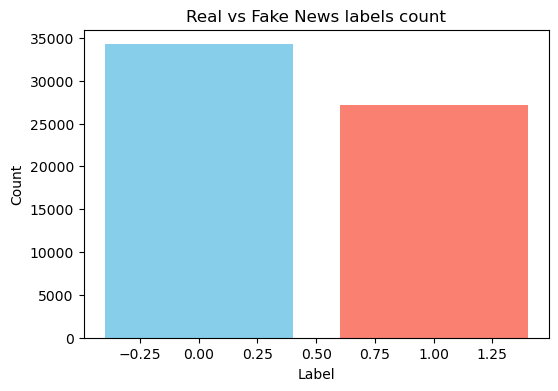

In [46]:
plt.figure(figsize=(6,4))
plt.bar(label_balance["label"], label_balance["count"], color=["skyblue", "salmon"])
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Real vs Fake News labels count")

plt.savefig(r"..\docs\EDA\target_label_balance.png", dpi=300, bbox_inches='tight')

plt.show()

**CONCLUSION:**

In [47]:
print(f"The difference between the labels 'real' and 'fake' is {label_diff}, which represents a minor percentage of {label_diff_percentage}%.")

The difference between the labels 'real' and 'fake' is 7081, which represents a minor percentage of 11.53%.


There is a slight **class imbalance** in the target label, favouring the **"fake news" type.**

## 2.2. Length of text:

**DATA PREPARATION:**

In [48]:
title_length = [len(y.split()) for x, y in df["title_cleaned"].items()]
# title_length
len(title_length)

61393

In [49]:
text_length = [len(y.split()) for x, y in df["text_cleaned"].items()]
len(text_length)

61393

In [50]:
label = list(df["label"])

In [51]:
# boolean masks:
mask_real = [lab == 1 for lab in label]
mask_fake = [lab == 0 for lab in label]

In [52]:
# apply boolean masks:
real_title_length = [t for t, m in zip(title_length, mask_real) if m]
fake_title_length = [t for t, m in zip(title_length, mask_fake) if m]

real_text_length = [t for t, m in zip(text_length, mask_real) if m]
fake_text_length = [t for t, m in zip(text_length, mask_fake) if m]

In [55]:
print(f"{min(real_title_length)} - {max(real_title_length)}")
print(f"{min(fake_title_length)} - {max(fake_title_length)}")
print(f"{min(real_text_length)} - {max(real_text_length)}")
print(f"{min(real_text_length)} - {max(real_text_length)}")

0 - 44
0 - 17
0 - 20674
0 - 20674


**VISUALIZATION:**

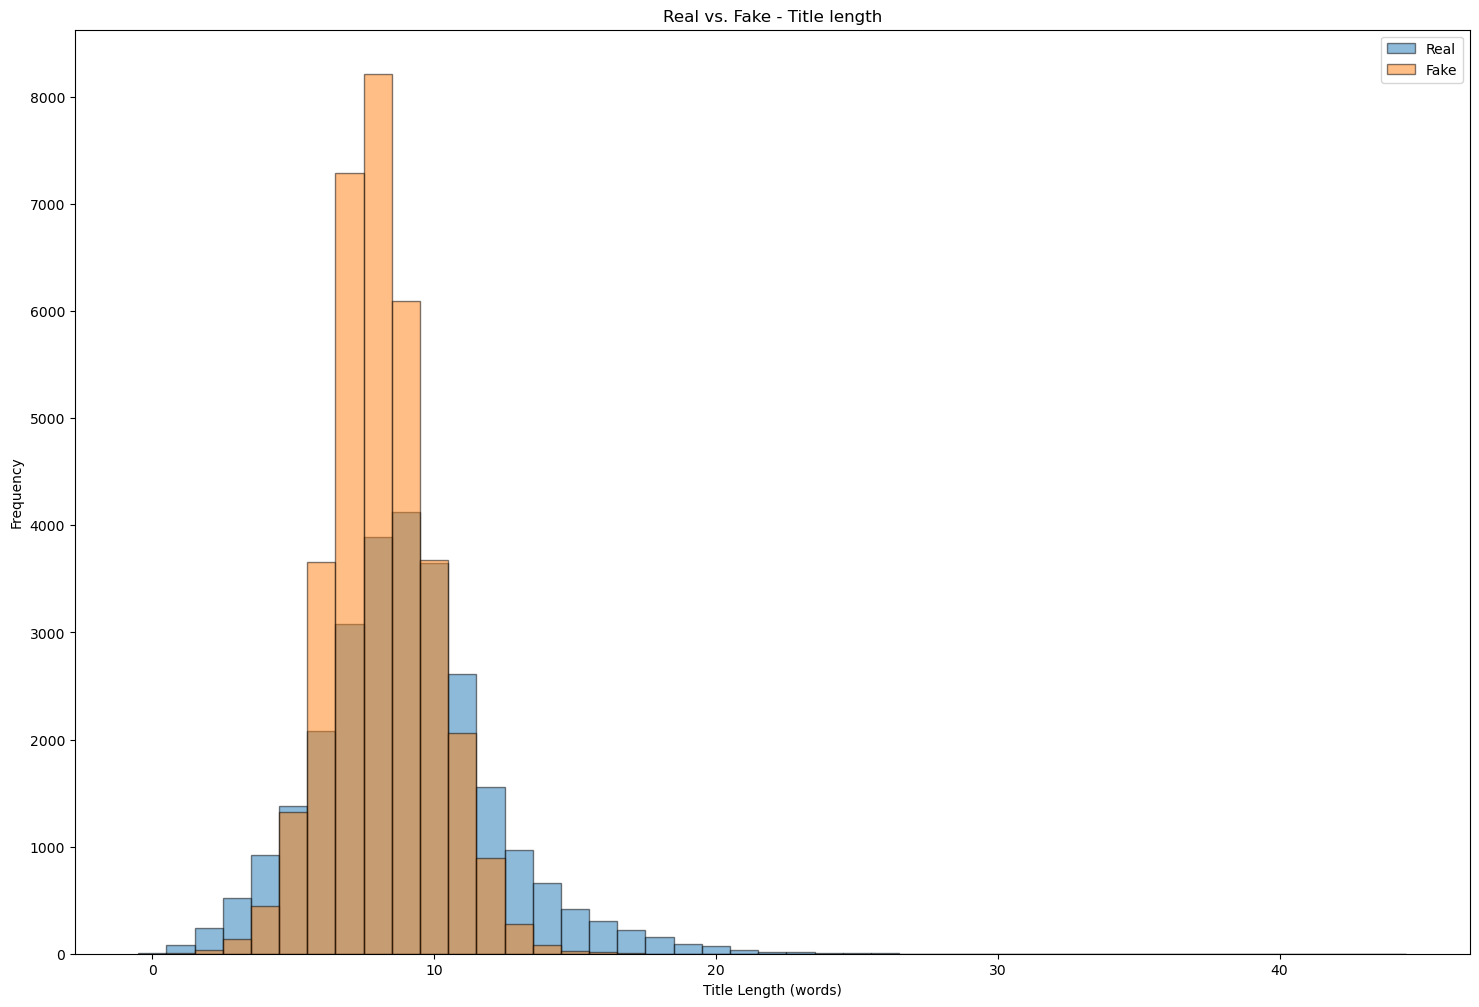

In [56]:
# alignment on bins:
all_lengths = np.array(real_title_length + fake_title_length)
bins = np.arange(all_lengths.min() - 0.5, all_lengths.max() + 1.5, 1)

plt.figure(figsize=(18, 12))
plt.hist(real_title_length, bins=bins, alpha=0.5, label="Real", edgecolor="black")
plt.hist(fake_title_length, bins=bins, alpha=0.5, label="Fake", edgecolor="black")
plt.xlabel("Title Length (words)")
plt.ylabel("Frequency")
plt.title("Real vs. Fake - Title length")
plt.legend()

plt.savefig(r"..\docs\EDA\text_length_title.png", dpi=300, bbox_inches='tight')

plt.show()

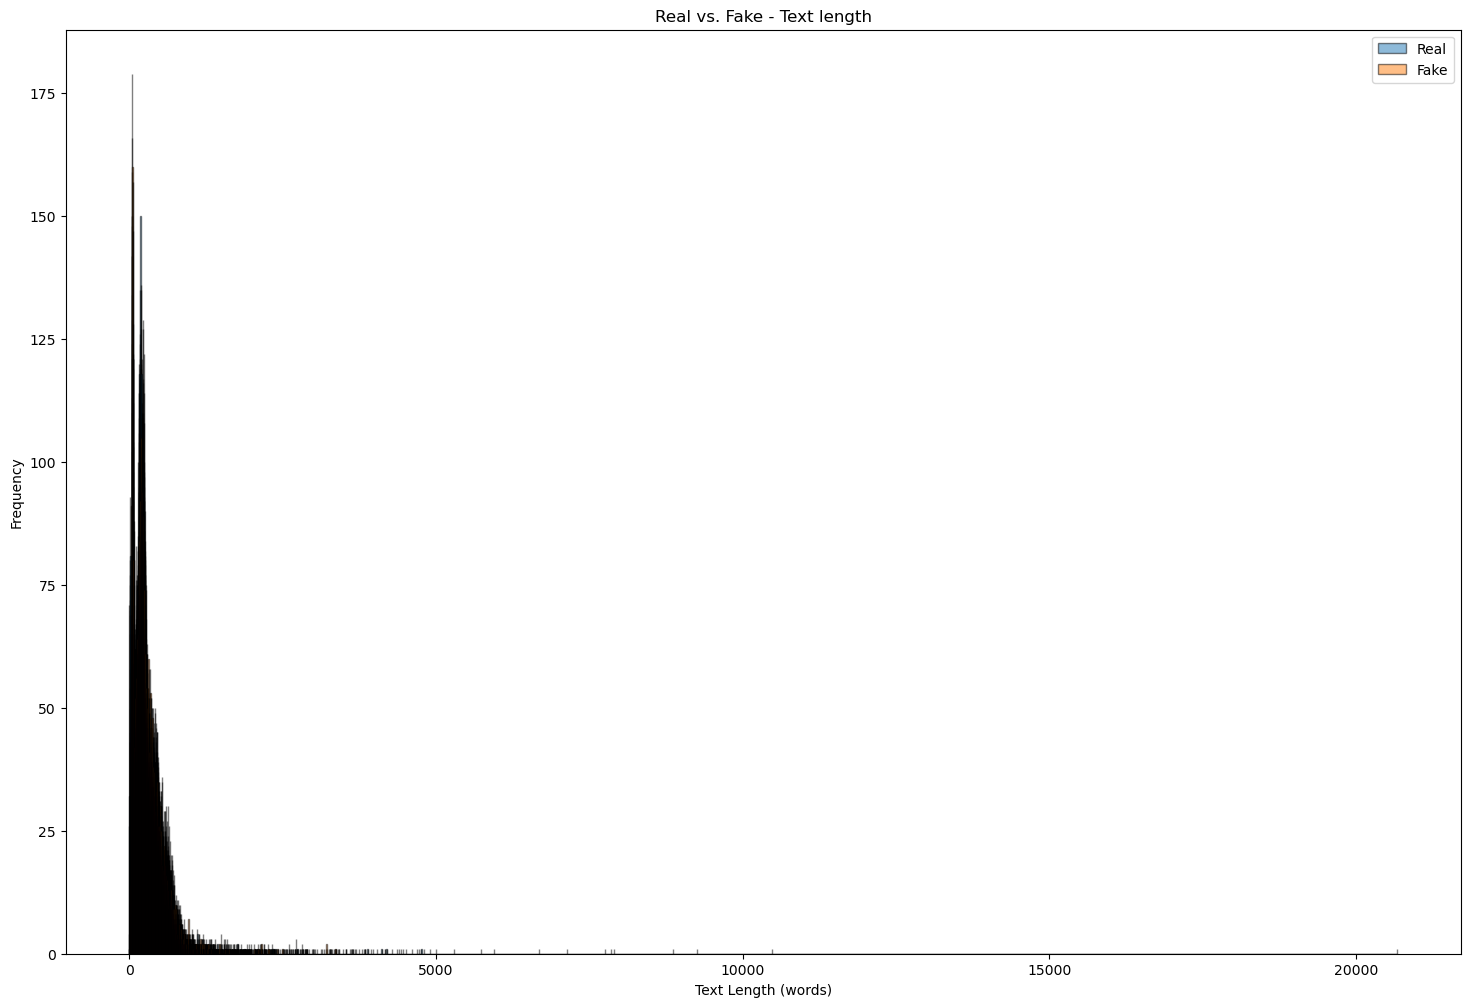

In [57]:
# alignment on bins:
all_lengths = np.array(real_text_length + fake_text_length)
bins = np.arange(all_lengths.min() - 0.5, all_lengths.max() + 1.5, 1)

plt.figure(figsize=(18, 12))
plt.hist(real_text_length, bins=bins, alpha=0.5, label="Real", edgecolor="black")
plt.hist(fake_text_length, bins=bins, alpha=0.5, label="Fake", edgecolor="black")
plt.xlabel("Text Length (words)")
plt.ylabel("Frequency")
plt.title("Real vs. Fake - Text length")
plt.legend()

plt.savefig(r"..\docs\EDA\text_length_text_outliers.png", dpi=300, bbox_inches='tight')

plt.show()

**CONCLUSION:**

**Titles:** while both classes overlap substantially, the **fake news** titles are **shorter** on average than the real news titles. **Real news** shows a **wider and more variable distribution**. **This is a weak discriminator.**   
**Texts:** both classes seem **heavily right-skewed**. Some **outliers** detection and removal should better show their distribution.  

## 2.3. Outliers detection:

In [58]:
def outlier_ratio(label, label_count, t, below, above):
    total = below + above
    ratio = round((total / label_count) * 100, 2)

    print(f"The ratio of {label} oultiers for {t} is: {ratio}%.")
    
    if ratio <= 5:
        print(f"The {label} outliers for the {t} can be removed.")
    else:
        print(f"The {label} outliers for the {t} CANNOTbe removed.")

In [59]:
label_balance

,label,count
0,0,34237
1,1,27156


In [60]:
fake_count = int(label_balance.loc[label_balance["label"] == 0, "count"].iloc[0])
real_count = int(label_balance.loc[label_balance["label"] == 1, "count"].iloc[0])

**REAL TITLE:**

In [61]:
vc = df["label"].value_counts()
fake_count = int(vc.get(0, 0))
real_count = int(vc.get(1, 0))
fake_count

34237

In [62]:
real_title_result = outlier_detection(real_title_length)

Lower bound: 1.0, Upper bound: 17.0.
There are 5 lower outliers.
There are 425 upper outliers.


In [63]:
outlier_ratio("real", real_count, "title_cleaned", real_title_result["below_values"], real_title_result["above_values"])

The ratio of real oultiers for title_cleaned is: 1.58%.
The real outliers for the title_cleaned can be removed.


In [64]:
df = drop_outliers(df, "title_cleaned", 1, real_title_result["lower_bound"], real_title_result["upper_bound"])

**FAKE TITLE:**

In [65]:
vc = df["label"].value_counts()
fake_count = int(vc.get(0, 0))
real_count = int(vc.get(1, 0))
fake_count

34237

In [66]:
fake_title_result = outlier_detection(fake_title_length)

Lower bound: 4.0, Upper bound: 12.0.
There are 175 lower outliers.
There are 404 upper outliers.


In [67]:
outlier_ratio("fake", fake_count, "title_cleaned", fake_title_result["below_values"], fake_title_result["above_values"])

The ratio of fake oultiers for title_cleaned is: 1.69%.
The fake outliers for the title_cleaned can be removed.


In [68]:
df = drop_outliers(df, "title_cleaned", 0, fake_title_result["lower_bound"], fake_title_result["upper_bound"])

**REAL TEXT:**

In [69]:
vc = df["label"].value_counts()
fake_count = int(vc.get(0, 0))
real_count = int(vc.get(1, 0))
fake_count

33658

In [70]:
real_text_result = outlier_detection(real_text_length)

Lower bound: -107.5, Upper bound: 536.5.
There is no lower outlier.
There are 2258 upper outliers.


In [71]:
outlier_ratio("real", real_count, "text_cleaned", real_text_result["below_values"], real_text_result["above_values"])

The ratio of real oultiers for text_cleaned is: 8.45%.
The real outliers for the text_cleaned CANNOTbe removed.


**FAKE TEXT:**

In [72]:
fake_text_result = outlier_detection(fake_text_length)

Lower bound: -286.0, Upper bound: 834.0.
There is no lower outlier.
There are 971 upper outliers.


In [73]:
outlier_ratio("fake", fake_count, "text_cleaned", fake_text_result["below_values"], fake_text_result["above_values"])

The ratio of fake oultiers for text_cleaned is: 2.88%.
The fake outliers for the text_cleaned can be removed.


**DATA PREPARATION CONCLUSION:**

**As there is no possibility to remove the oultiers from the real text, the distribution of both text will be compared using the log() function.**

In [74]:
title_length = [len(y.split()) for x, y in df["title_cleaned"].items()]
# title_length
len(title_length)

60384

In [75]:
text_length = [len(y.split()) for x, y in df["text_cleaned"].items()]
len(text_length)

60384

In [76]:
label = list(df["label"])

In [77]:
# boolean masks:
mask_real = [lab == 1 for lab in label]
mask_fake = [lab == 0 for lab in label]

In [78]:
# apply boolean masks:
real_title_length = np.array([t for t, m in zip(title_length, mask_real) if m])
fake_title_length = np.array([t for t, m in zip(title_length, mask_fake) if m])

real_text_length = np.array([t for t, m in zip(text_length, mask_real) if m])
fake_text_length = np.array([t for t, m in zip(text_length, mask_fake) if m])

In [79]:
real_log = np.log1p(real_text_length)
fake_log = np.log1p(fake_text_length)

**VISUALIZATION:**

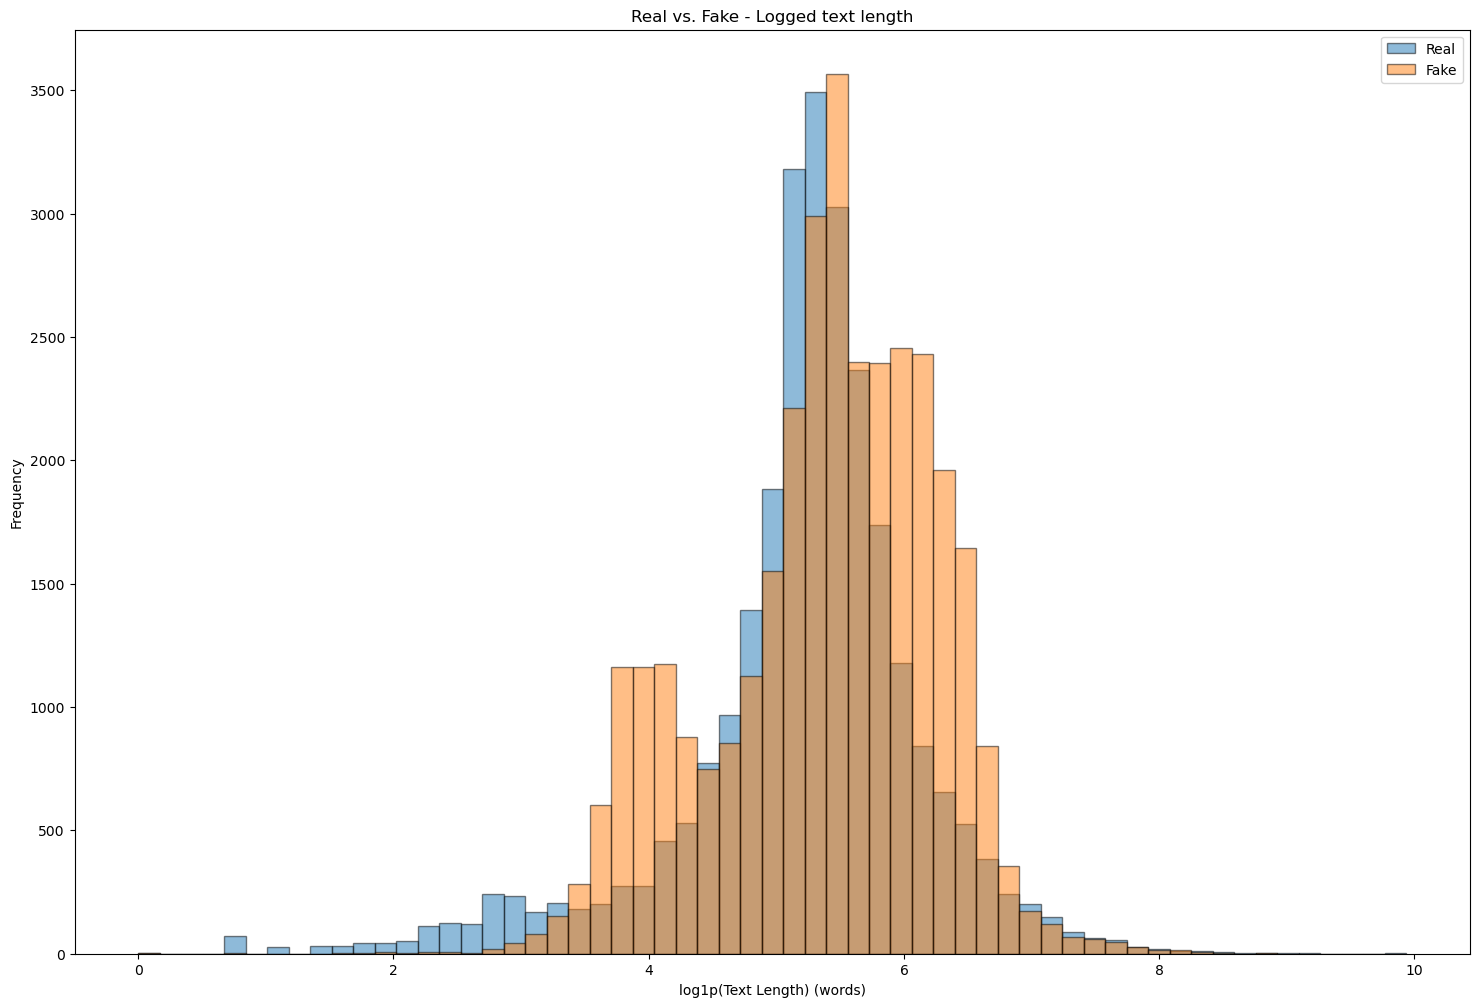

In [80]:
# alignment on bins:
all_log = np.concatenate([real_log, fake_log])
bins = np.linspace(all_log.min(), all_log.max(), 60)

plt.figure(figsize=(18, 12))
plt.hist(real_log, bins=bins, alpha=0.5, label="Real", edgecolor="black")
plt.hist(fake_log, bins=bins, alpha=0.5, label="Fake", edgecolor="black")
plt.xlabel("log1p(Text Length) (words)")
plt.ylabel("Frequency")
plt.title("Real vs. Fake - Logged text length")
plt.legend()

plt.savefig(r"..\docs\EDA\text_length_text.png", dpi=300, bbox_inches='tight')

plt.show()

**CONCLUSION:**

The two distribution **overlaps** somewhat strongly.   
However, there is a tendency from **"fake news"** articles for slightly **longer text**.  
The **"text length"** feature can be considered a **weak discriminator** but nonetheless interesting.  

## 2.4. Vocabulary richness:

**DATA PREPARATION:**

In [83]:
labels = df["label"]
texts = df["text_cleaned"]

mask_real = labels == 1
mask_fake = labels == 0

text_real = texts[mask_real]
text_fake = texts[mask_fake]

text_fake

3        dozen politically active pastor come private d...
11       brussels reuters british prime minister theres...
12       washington reuters charles schumer democrat u....
14       sport fan turn espn protest network social pol...
15       rio de janeiro sao paulo reuters billionaire m...
                               ...                        
72124    paris age donald j. trump brexit resurgent fre...
72126    flag desert hot springs condor gun shop fly ha...
72129    washington reuters hacker believe work russian...
72131    migrant refuse leave train refugee camp hungar...
72132    mexico city reuters donald trump combative sty...
Name: text_cleaned, Length: 33658, dtype: object

In [84]:
real_avg, real_r = vocab_richness(text_real, "real")


Real texts shows a vocabulary richness index of: 0.70


In [85]:
fake_avg, fake_r = vocab_richness(text_fake, "fake")

Fake texts shows a vocabulary richness index of: 0.68


**CONCLUSION:**

Both **"real news"** texts and **"fake news"** share a close and somewhat **similar index of richness in their vocabulary**.  
Therefore, a vocabulary-richness feature is unlikely to help the model distinguish between the two classes.  
**This is a weak discriminator.**  

## 2.5. Terms frequency:

**DATA PREPARATION:**

**Titles:**

In [86]:
title_top_real, title_top_fake = tf_search(df, "title_cleaned", 20, 2, 0.9, (2,2))

Top real news terms:
 term
donald trump        945
hillary clinton     614
white house         305
president trump     287
fox news            276
trump video         229
trump supporter     228
ted cruz            214
bernie sanders      192
president obama     178
anti trump          171
year old            153
watch trump         151
fake news           136
paul ryan           131
trump supporters    126
supreme court       125
trump campaign      124
trump win           119
kellyanne conway    108
Name: real, dtype: int64
Top fake news terms:
 term
new york                6249
york times              6056
white house              944
donald trump             818
north korea              702
trump say                384
hillary clinton          347
supreme court            331
islamic state            318
briefing new             196
puerto rico              183
travel ban               175
say trump                162
south korea              161
trump administration     157
evenin

**Texts:**

In [87]:
text_top_real, text_top_fake = tf_search(df, "text_cleaned", 20, 20, 0.95, (2,2))

Top real news terms:
 term
donald trump       18785
hillary clinton    11683
united states       8604
feature image       7507
white house         7007
twitter com         5586
pic twitter         5311
new york            5045
president obama     4173
getty images        4120
year old            3447
fox news            3088
president trump     2662
barack obama        2302
secretary state     2274
trump say           2174
trump supporter     2169
american people     2122
trump campaign      2112
look like           2100
Name: real, dtype: int64
Top fake news terms:
 term
united states         21058
mr trump              16625
donald trump          16143
white house           13299
new york              12373
president donald       6763
washington reuters     6512
islamic state          6102
trump say              6101
north korea            5999
hillary clinton        5909
prime minister         5516
official say           5285
say statement          5245
barack obama           4675
s

**VISUALIZATION:**

**Titles:**

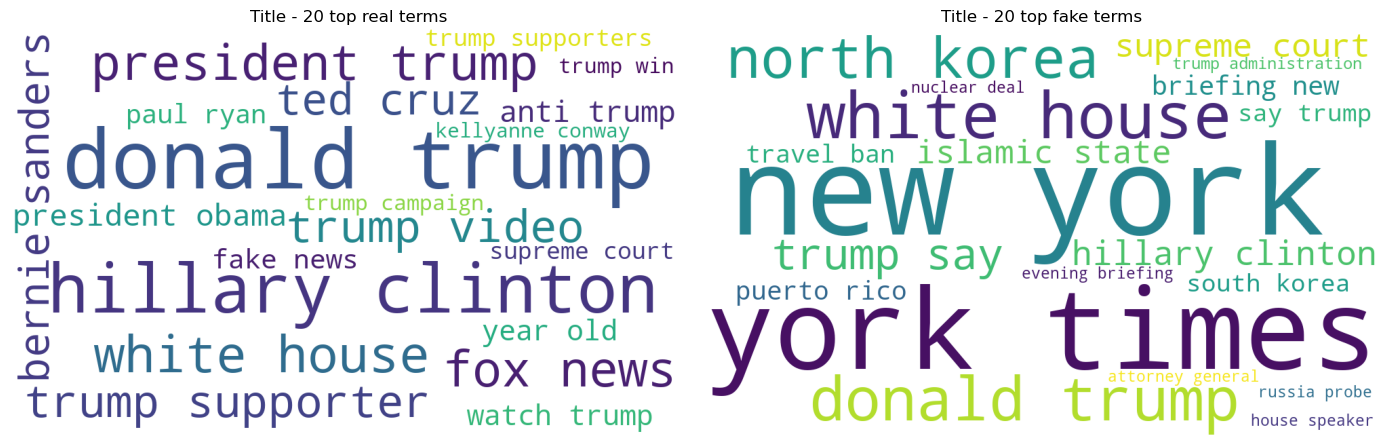

In [93]:
wordcloud_plot(title_top_real, title_top_fake, "title", 20)

**Texts:**

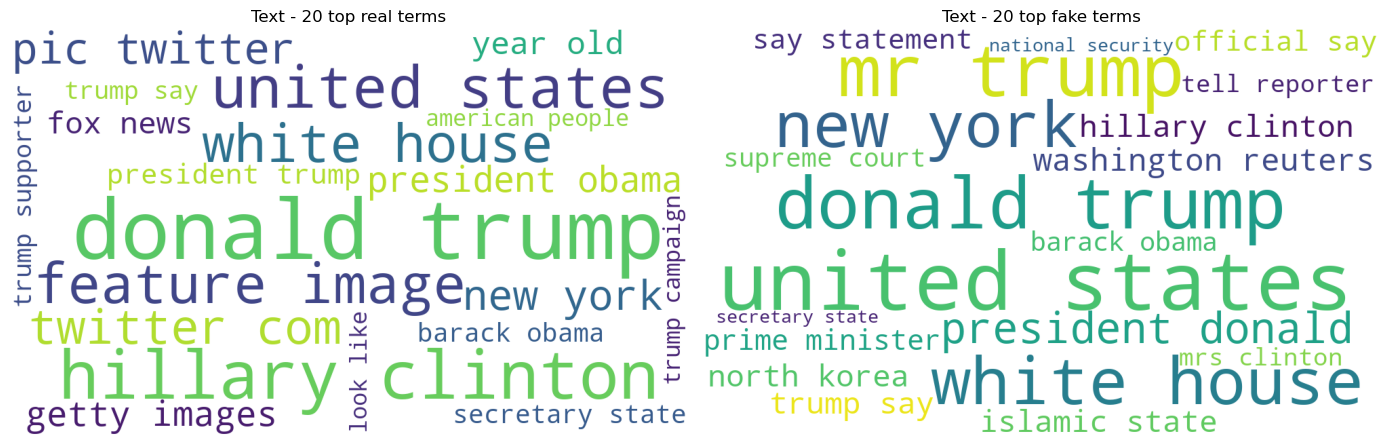

In [94]:
wordcloud_plot(text_top_real, text_top_fake, "text", 20)

**CONCLUSION:**

There is a **strong overlap** in both titles and texts with the top entities being the same, which makes this portential feature a **weak discriminator**.  

**However:**  

**Title:** **fake news** favour more **institutional** and **geopolitical** sentences whereas **real news** tilt towards **campaign** and **opinion** terms.  
**Text:** **fake news** favour more **reporting style** while **real news** contain more **social medias** topics.  

## 2.6. POS - proper nouns and other nouns:

**GENERAL DATA PREPARATION:**

In [95]:
# masks:
text_original = df_raw["text"]
title_original = df_raw["title"]

real_mask = df_raw["label"] == 1
fake_mask = df_raw["label"] == 0

real_title_original = title_original[real_mask]
fake_title_original = title_original[fake_mask]

real_text_original = text_original[real_mask]
fake_text_original = text_original[fake_mask]

### 2.6.1. Proper nouns and other nouns ratio:

**DATA PREPARATION:**

In [96]:
propn_title_r, noun_title_r = PROPN_NOUN_ratios(real_title_original)
propn_text_r, noun_text_r = PROPN_NOUN_ratios(real_text_original)
propn_title_f, noun_title_f = PROPN_NOUN_ratios(fake_title_original)
propn_text_f, noun_text_f = PROPN_NOUN_ratios(fake_text_original)

In [97]:
ratios = [propn_title_r, noun_title_r, propn_text_r, noun_text_r, propn_title_f, noun_title_f, propn_text_f, noun_text_f]
keys = ["propn_title_r", "noun_title_r", "propn_text_r", "noun_text_r", "propn_title_f", "noun_title_f", "propn_text_f", "noun_text_f"]

ratios_avg = []
for r in ratios:
    avg = round(np.mean(r), 2)
    ratios_avg.append(avg)

ratios_avg_dict = dict(zip(keys, ratios_avg))
print(ratios_avg_dict)

{'propn_title_r': 0.41, 'noun_title_r': 0.12, 'propn_text_r': 0.14, 'noun_text_r': 0.18, 'propn_title_f': 0.33, 'noun_title_f': 0.22, 'propn_text_f': 0.15, 'noun_text_f': 0.2}


**VISUALIZATION:**

In [101]:
pairs = [
    ("Title (Real)", "propn_title_r", "noun_title_r"),
    ("Text  (Real)", "propn_text_r",  "noun_text_r"),
    ("Title (Fake)", "propn_title_f", "noun_title_f"),
    ("Text  (Fake)", "propn_text_f",  "noun_text_f")
]

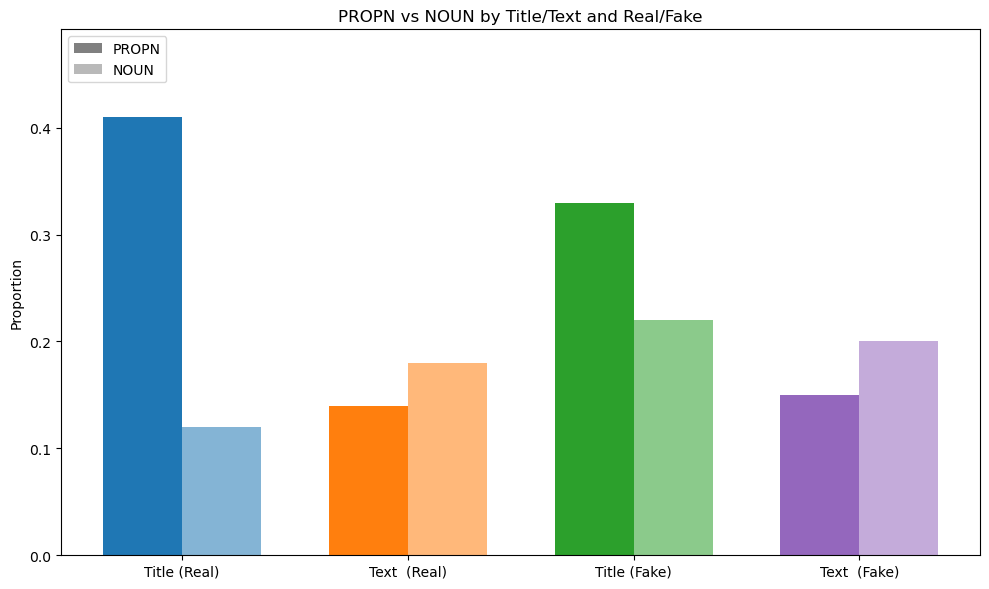

In [102]:
x = np.arange(len(pairs))
w = 0.35
pair_colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple"]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (label, k_propn, k_noun) in enumerate(pairs):
    ax.bar(x[i]-w/2, ratios_avg_dict[k_propn], width=w, color=pair_colors[i])        # PROPN
    ax.bar(x[i]+w/2, ratios_avg_dict[k_noun],  width=w, color=pair_colors[i], alpha=0.55)  # NOUN

ax.set_xticks(x)
ax.set_xticklabels([p[0] for p in pairs])
ax.set_ylabel("Proportion")
ax.set_title("PROPN vs NOUN by Title/Text and Real/Fake")
ax.set_ylim(0, max(ratios_avg_dict.values()) * 1.2)

# Simple legend
ax.legend(handles=[
    Patch(facecolor="gray", label="PROPN"),
    Patch(facecolor="gray", alpha=0.55, label="NOUN")
], loc="upper left")

plt.tight_layout()

plt.savefig(r"..\docs\EDA\prop_nouns_ratio.png", dpi=300, bbox_inches='tight')

plt.show()

**CONCLUSION**:

**Title:**  
**Real news** headlines lean more on **proper nouns** whereas **fake news** titles use more **generic nouns**. This is a **strong discriminator**.  

**Text:**  
The **differences** in article texts are **small**. This is a **weak discriminator.**  

### 2.6.2. Proper nouns frequency:

**DATA PREPARATION:**

In [103]:
series_original = [real_title_original, fake_title_original, real_text_original, fake_text_original]
series_original_keys = ["real_title_original", "fake_title_original", "real_text_original", "fake_text_original"]

In [104]:
series_original_results = []

for s in series_original:
    r = PROPN_frequency(s)
    series_original_results.append(r)

so_propn_freq = dict(zip(series_original_keys, series_original_results))

In [105]:
# print(so_propn_freq)

**VISUALIZATION:**

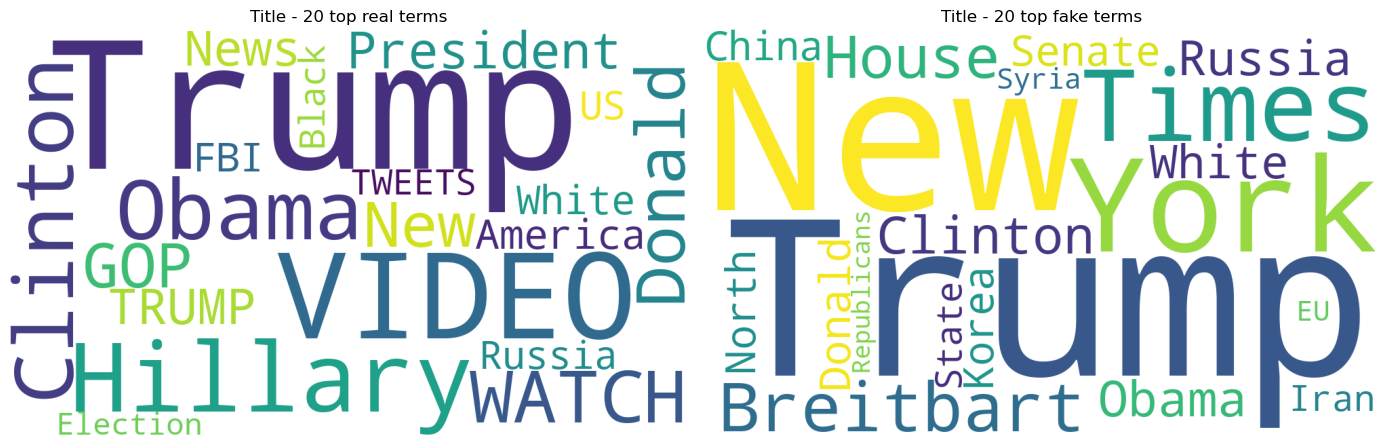

In [108]:
wordcloud_plot(so_propn_freq["real_title_original"].to_frame("real"), so_propn_freq["fake_title_original"].to_frame("fake"), "title", 20, "pnf")

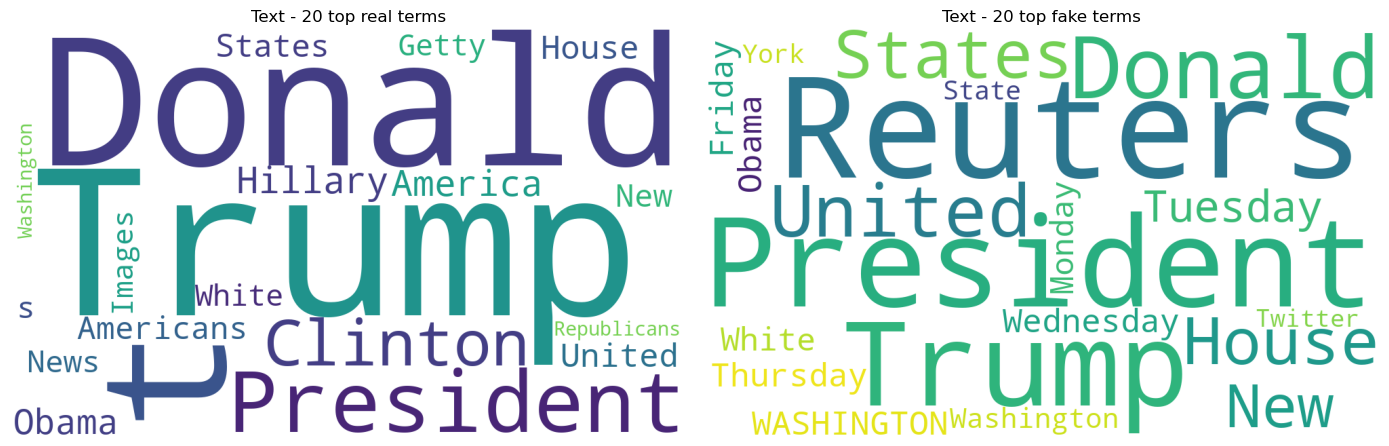

In [109]:
wordcloud_plot(so_propn_freq["real_text_original"].to_frame("real"), so_propn_freq["fake_text_original"].to_frame("fake"), "text", 20, "pnf")

**CONCLUSION:**

**The PROPN document frequency largely overlaps.** This is a **weak discriminator.**

**However:**

**Fake:**  
Titles and texts use more **institutional** and **"wire-style"** names.

**Real:**  
Titles and texts include more **media** and **social medias** terms.  
slightly more "action-driven** or **sensational** terms.  

## 2.7. NER - named entities recognition:

### 2.7.1. NER - Ratios:

**DATA PREPARATION:**

In [110]:
ents_original_ratios = []

for s in series_original:
    r = entity_ratio(s)
    ents_original_ratios.append(r)

so_ents_ratios = dict(zip(series_original_keys, ents_original_ratios))
# print(so_ents_ratios)

In [111]:
ents_ratios_avg = []
for k, v in so_ents_ratios.items():
    avg = round(np.mean(v), 5)
    ents_ratios_avg.append(avg)

ents_ratios_avg_dict = dict(zip(series_original_keys, ents_ratios_avg))
print(ents_ratios_avg_dict)

{'real_title_original': 0.10219, 'fake_title_original': 0.15817, 'real_text_original': 0.0655, 'fake_text_original': 0.07845}


**VISUALIZATION:**

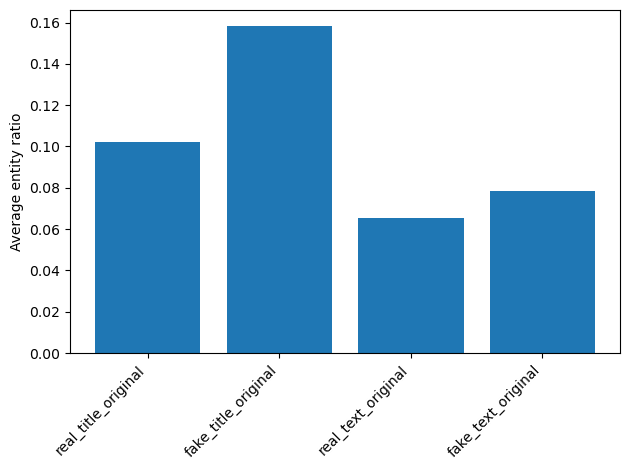

In [112]:
plt.bar(list(ents_ratios_avg_dict .keys()), list(ents_ratios_avg_dict .values()))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average entity ratio')
plt.tight_layout()

plt.savefig(r"..\docs\EDA\ner_ratio.png", dpi=300, bbox_inches='tight')

plt.show()

**CONCLUSION:**

**Title:**  
**"Fake news"** titles have a **higher entities density**. This is a **strong discriminator**.  

**Text:**  
**Small difference** between "fake news" and "real news". This is a **weak discriminator**. 

### 2.7.2. NER - Frequency:

**DATA PREPARATION:**

In [113]:
ents_original_freq = []

for s in series_original:
    r = entity_freq(s)
    ents_original_freq.append(r)

so_ents_freq = dict(zip(series_original_keys, ents_original_freq))

In [114]:
print(so_ents_freq)

{'real_title_original': Trump              1749
Hillary            1060
Obama               929
Donald Trump        711
GOP                 515
Hillary Clinton     504
FBI                 494
TWEETS              441
Russia              438
US                  395
Clinton             373
CNN                 328
HILLARY             312
U.S.                274
OBAMA               269
America             219
WOW                 200
TRUMP               193
Syria               181
Putin               164
dtype: int64, 'fake_title_original': Trump                 4894
The New York Times    4441
U.S.                  3653
Russia                1080
Obama                 1059
Clinton                851
White House            820
China                  762
Donald Trump           668
North Korea            645
Senate                 616
Iran                   594
Syria                  565
House                  548
EU                     539
U.N.                   481
Turkey                 409


**VISUALIZATION:**

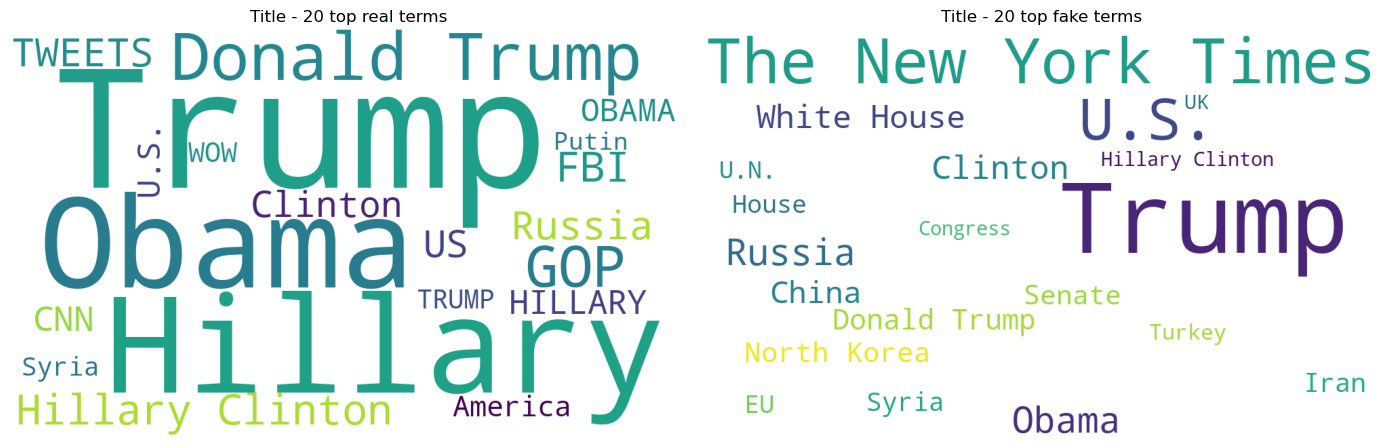

In [115]:
wordcloud_plot(so_ents_freq["real_title_original"].to_frame("real"), so_ents_freq["fake_title_original"].to_frame("fake"), "title", 20, "nerf")

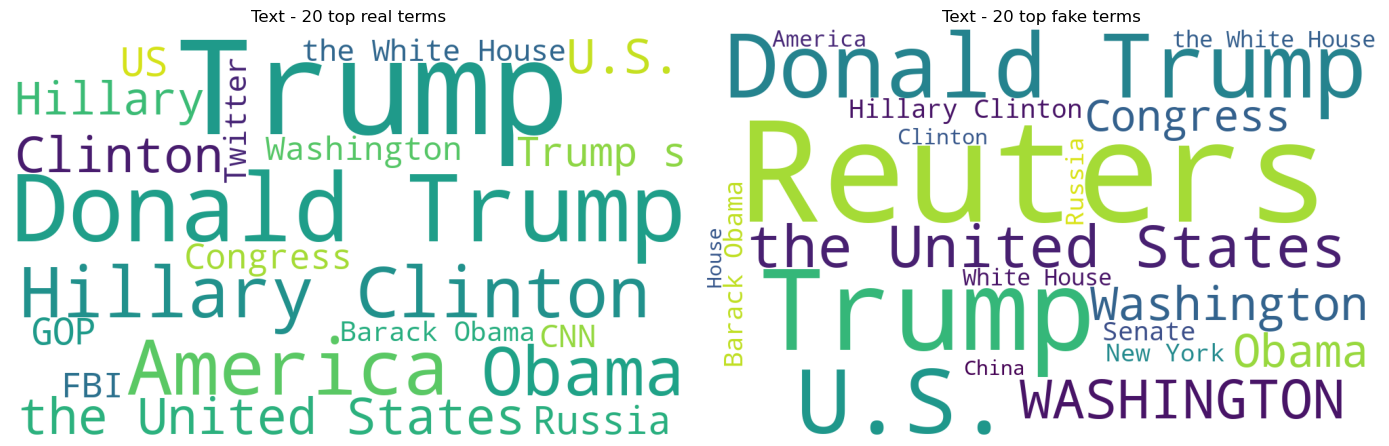

In [117]:
wordcloud_plot(so_ents_freq["real_text_original"].to_frame("real"), so_ents_freq["fake_text_original"].to_frame("fake"), "text", 20, "nerf")

**CONCLUSION:**

**The named entities recognition (NER) frequency largely overlaps.** This is a **weak discriminator.**

**However:**

**Fake:**  
Titles and texts use more **institutional** and **"wire-style"** names.

**Real:**  
Titles and texts include more **person-centric & social medias** terms. 

## 2.8. Polarity and subjectivity:

In [118]:
series_original = [real_title_original, fake_title_original, real_text_original, fake_text_original]
series_original_keys = ["real_title_original", "fake_title_original", "real_text_original", "fake_text_original"]

**DATA PREPRATION:**

In [119]:
pol = []
subj = []

for s in series_original:
    p, sub = polarity_subjectivity(s)
    pol.append(p)
    subj.append(sub)

# print(len(pol))
# print(len(subj))

so_pol_subj = {k :(p, s) for k, p, s in zip(series_original_keys, pol, subj)}
# print(so_pol_subj)

In [120]:
so_pol_subj_mean = dict()

for k, v in so_pol_subj.items():
    p = round(np.mean(v[0]), 5)
    s = round(np.mean(v[1]), 5)
    so_pol_subj_mean[k] = (p, s)

print(so_pol_subj_mean)

{'real_title_original': (0.00913, 0.33249), 'fake_title_original': (0.03825, 0.23618), 'real_text_original': (0.06454, 0.44125), 'fake_text_original': (0.06192, 0.38302)}


**VISUALIZATION:**

In [121]:
pairs_pol_subj = [
    ("Title (Real)", "real_title_original"),
    ("Text  (Real)", "real_text_original"),
    ("Title (Fake)", "fake_title_original"),
    ("Text  (Fake)", "fake_text_original")
]

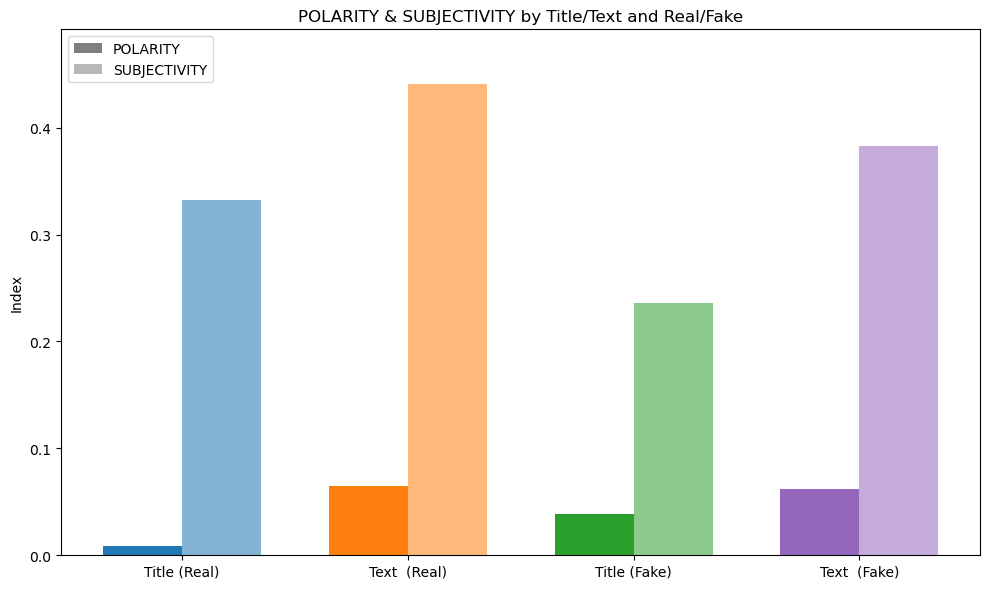

In [122]:
x = np.arange(len(pairs_pol_subj))
w = 0.35
pair_col = ["tab:blue", "tab:orange", "tab:green", "tab:purple"]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (label, typ) in enumerate(pairs_pol_subj):
    ax.bar(x[i]-w/2, so_pol_subj_mean[typ][0], width=w, color=pair_col[i])        # POLARITY
    ax.bar(x[i]+w/2, so_pol_subj_mean[typ][1],  width=w, color=pair_col[i], alpha=0.55)  # SUBJECTIVITY

ax.set_xticks(x)
ax.set_xticklabels([p[0] for p in pairs])
ax.set_ylabel("Index")
ax.set_title("POLARITY & SUBJECTIVITY by Title/Text and Real/Fake")
ax.set_ylim(0, max(ratios_avg_dict.values()) * 1.2)

# Simple legend
ax.legend(handles=[
    Patch(facecolor="gray", label="POLARITY"),
    Patch(facecolor="gray", alpha=0.55, label="SUBJECTIVITY")
], loc="upper left")

plt.tight_layout()

plt.savefig(r"..\docs\EDA\polarity_subjectivity.png", dpi=300, bbox_inches='tight')

plt.show()

**CONCLUSION:**

**Results meaning:**   
**Polarity**: range from -1 to +1, with -1 = very negative, 0 = neutral and +1 = very positive.    
**Subjectivity**: range from 0 to 1, 0 = very objective and factual and 1 = very subjective  and opinionated.  

**Analysis:**  

&nbsp;&nbsp;&nbsp;&nbsp;**Polarity**:   
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Title:** **"fake news"** reveal more polarity than **"real news"**. This is a **strong discriminator**.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Text:** **"fake news"** and **"real news"** show quite similar polarity. This is a **weak discriminator**.  

&nbsp;&nbsp;&nbsp;&nbsp;**Subjectivity**:  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Title:** **"real news"** reveal **more subjectivity** than **"fake news"**. This is a **strong discriminator**.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**Text:** **"real news"** reveal **more subjectivity** than **"fake news"**. This is a **strong discriminator**.  

## 2.9. Readability:

**DATA PREPARATION:**

In [123]:
# df_title_text_label = pd.concat([df_title_text, df["label"]], axis=1)
# df_title_text_label.head()

In [124]:
df_raw.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1


In [125]:
df_readability = readability(df_raw, "text")
# df_readability.head()

C:\Users\Benoit Loze\AppData\Local\Temp\ipykernel_33548\841929740.py:16: DeprecationWarning: The 'avg_sentence_length' method has been deprecated due to being the same as 'words_per_sentence'. This method will be removed in thefuture.
  "avg_sentence_length":          textstat.avg_sentence_length(t),


In [126]:
df_readability_complete = readability(df_readability, "title")
# df_readability_complete.head()

C:\Users\Benoit Loze\AppData\Local\Temp\ipykernel_33548\841929740.py:16: DeprecationWarning: The 'avg_sentence_length' method has been deprecated due to being the same as 'words_per_sentence'. This method will be removed in thefuture.
  "avg_sentence_length":          textstat.avg_sentence_length(t),


In [127]:
discriminative_text = (df_readability_complete.groupby("label")[[
    "text_flesch_reading_ease",
    "text_flesch_kincaid_grade",
    "text_gunning_fog",
    "text_avg_sentence_length",
    "text_avg_syllables_per_word",
    "text_polysyllab_pct"  
]].mean().round(3))
discriminative_text.head()

,text_flesch_reading_ease,text_flesch_kincaid_grade,text_gunning_fog,text_avg_sentence_length,text_avg_syllables_per_word,text_polysyllab_pct
label,,,,,,
0,45.842,12.144,14.823,21.249,1.648,0.172
1,50.026,11.371,13.872,20.492,1.607,0.158


In [128]:
discriminative_title = (df_readability_complete.groupby("label")[[
    "title_flesch_reading_ease",
    "title_flesch_kincaid_grade",
    "title_gunning_fog",
    "title_avg_sentence_length",
    "title_avg_syllables_per_word",
    "title_polysyllab_pct"  
]].mean().round(3))
discriminative_title.head()

,title_flesch_reading_ease,title_flesch_kincaid_grade,title_gunning_fog,title_avg_sentence_length,title_avg_syllables_per_word,title_polysyllab_pct
label,,,,,,
0,49.257,8.936,11.549,10.252,1.74,0.195
1,48.564,9.598,12.272,12.529,1.72,0.195


**VISUALIZATION:**

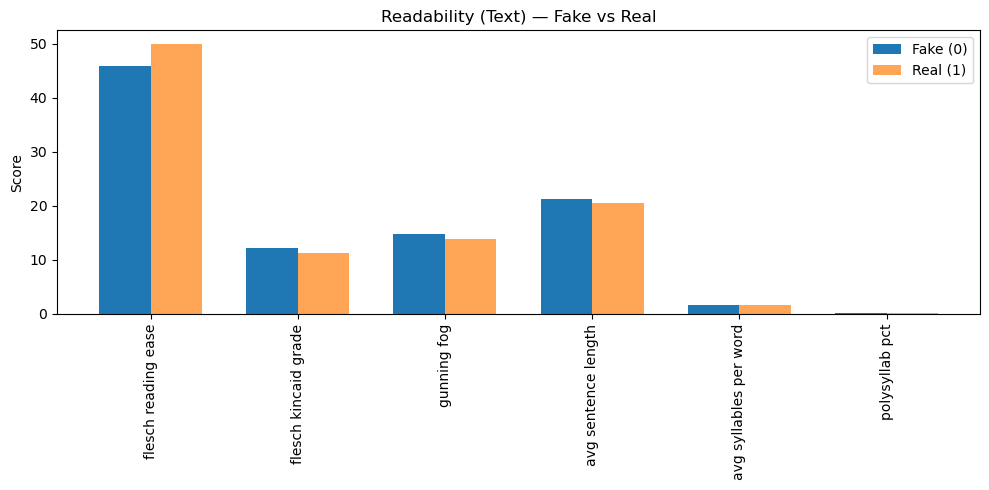

In [130]:
readability_plot(discriminative_text, "text")

In [131]:
discriminative_title.head()

,title_flesch_reading_ease,title_flesch_kincaid_grade,title_gunning_fog,title_avg_sentence_length,title_avg_syllables_per_word,title_polysyllab_pct
label,,,,,,
0,49.257,8.936,11.549,10.252,1.74,0.195
1,48.564,9.598,12.272,12.529,1.72,0.195


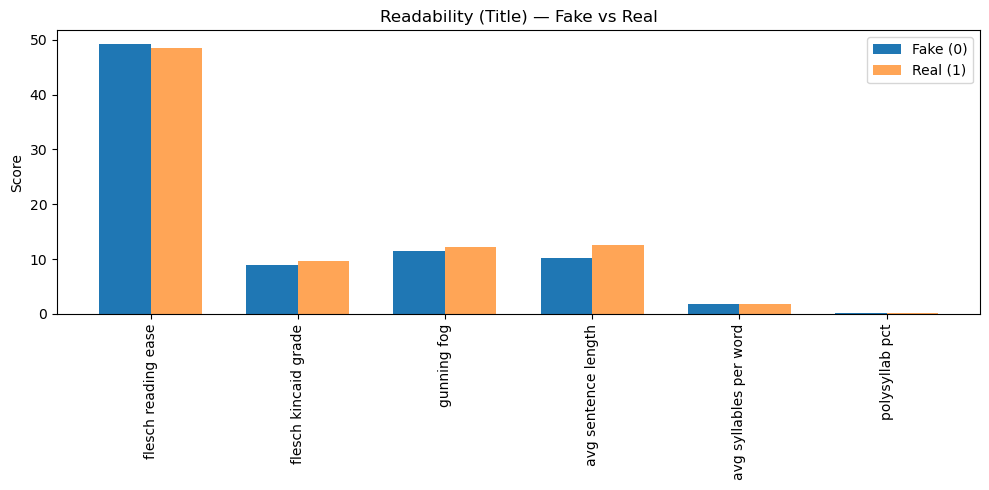

In [132]:
readability_plot(discriminative_title, "title")

**CONCLUSION:**

**Results meaning:**  

"flesch_reading_ease": **easier text when Higher**.   
"flesch_kincaid_grade": **easier text when Lower**.   
"gunning_fog": **easier text when Lower**.   
"smog_index": **easier text when Lower**.       
"coleman_liau_index": **easier text when Lower**.       
"automated_readability_index": **easier text when Lower**.    
"dale_chall": **easier text when Lower**.        
"avg_sentence_length": **easier text when Lower**.       
"avg_syllables_per_word": **easier text when Lower**.      
"polysyllab_pct": **easier text when Lower**.  

**Analysis:**  

&nbsp;&nbsp;&nbsp;&nbsp;**Text**: **"Real news"** are easier to read. **This is a strong dscriminator.**  
&nbsp;&nbsp;&nbsp;&nbsp;**Title**: **"Fake news"** are easier to read. **This is a strong dscriminator.**  


# 3. General conclusion:  

In this data wrangling and exploratory data analysis (EDA) stage, we explored the potential discriminative power of several features, which are:    
    - Length of text.  
    - Vocabulary richness.    
    - Terms ferequency.  
    - POS: proper nouns and other nouns.  
    - NER: named entities recognition.  
    - Polarity and subjectivity.  
    - Readability.

The **RESULTS** are as per below:


&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**WEAK DISCRIMINATORS:**   
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- Length of text.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- Vocabulary richness.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- Terms frequency.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- POS proper noun/other noun ratio text.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- NER ratio text.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- NER frequency.  

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;**STRONG DISCRIMINATORS:**  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- POS proper noun/other noun ratio title.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- NER ratio title.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- Polarity title.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- Polarity text.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- Subjectivity title.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- Subjectivity text.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- Readability title.  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;- Readability text.  


# 4. Data save:

In [114]:
df_file_path = r"..\data\processed\df_data_wrangling_eda_reliable_ds.csv"

In [115]:
# df.to_csv(df_file_path, index=False, encoding="utf-8")